In [1]:
# Basic imports
from HARK.models import IndShockConsumerType
import matplotlib.pyplot as plt
from HARK.utilities import make_exponential_grid
from HARK.ConsumptionSaving.ConsIndShockModel import init_lifecycle

In [2]:
# Define grids
wealth_grid = {"min": 0.0, "max": 40.0, "N": 300, "order": 2.0}
con_grid = {"min": 0.0, "max": 10.0, "N": 201}
my_grid_specs = {"kNrm": wealth_grid, "cNrm": con_grid}

In [3]:
# Make a life-cycle agent
T = 50
trivial_LC_params = {
    "PermGroFac": T * [1.0],
    "PermShkStd": T * [0.1],
    "TranShkStd": T * [0.1],
    "LivPrb": 30 * [1.0] + [0.99] + 19 * [1.0],
    "Rfree": T * [1.03],
    "IncUnemp": 0.0,
    "kLogInitMean": 2.0,
    "T_cycle": T,
}
MyType = IndShockConsumerType(**init_lifecycle)

In [4]:
# Define a simple function for plotting SSJs
def plot_SSJ(jac, S, outcome, shock, t_max=None):
    top = jac.shape[0] + 1 if t_max is None else t_max + 1
    if type(S) is int:
        S = [S]
    for s in S:
        plt.plot(jac[:, s], "-", label="s=" + str(s))
    plt.legend()
    plt.xlabel(r"time $t$")
    plt.ylabel("rate of change of " + outcome)
    plt.title("SSJ for " + outcome + " with respect to " + shock + r" at time $s$")
    plt.tight_layout()
    plt.xlim(-1, top)
    plt.show()

In [5]:
# Make HA-SSJs
J_A_R, J_C_R = MyType.make_basic_SSJ(
    "Rfree",
    ["aNrm", "cNrm"],
    grids=my_grid_specs,
    verbose=True,
    offset=True,
    norm="PermShk",
    age_agg=True,
)

Solving the long run model took 0.049 seconds.
Making the transition matrix for the long run model took 3.002 seconds.
Finding the long run steady state took 0.060 seconds.
Constructing expectation vectors took 1.016 seconds.
Making fake news arrays for each period of the problem took 45.347 seconds.
Constructing the sequence space Jacobians took 1.004 seconds.


In [6]:
# plt.plot(out[0,20,:,0])
# plt.show()

k_grid = make_exponential_grid(0.0, 40.0, 200, order=2.0)
# plt.plot(k_grid, out[0][0,0,:])
# plt.show()

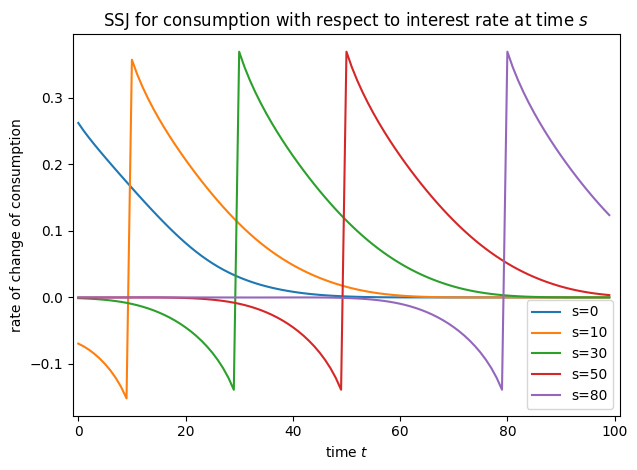

In [7]:
plot_SSJ(J_C_R, [0, 10, 30, 50, 80], "consumption", "interest rate")

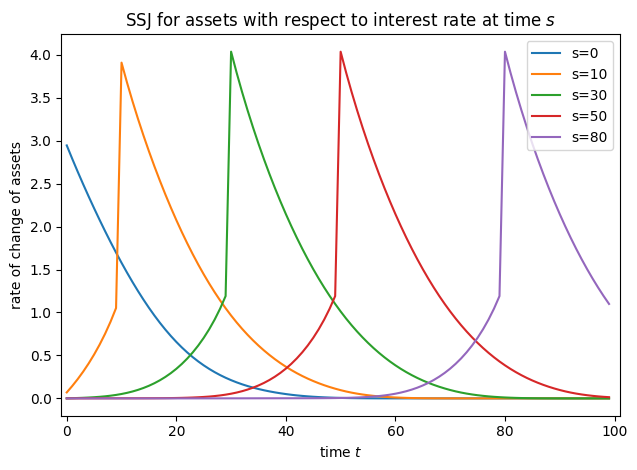

In [8]:
plot_SSJ(J_A_R, [0, 10, 30, 50, 80], "assets", "interest rate")